<a href="https://colab.research.google.com/github/7vckingrck/VKR/blob/main/Volkov_VKR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 csv
import random
import time
from datetime import datetime, timedelta

def generate_random_ip():
    return f"{random.randint(0, 255)}.{random.randint(0, 255)}.{random.randint(0, 255)}.{random.randint(0, 255)}"

def generate_random_mac():
    return ':'.join(['{:02x}'.format(random.randint(0, 255)) for _ in range(6)])

def generate_random_service():
    services = ['Telegram', 'Google', 'YouTube', 'Facebook', 'Instagram', 'Twitter', 'Netflix', 'Spotify', 'WhatsApp', 'hh.ru', 'VK']
    return random.choice(services)

def generate_random_time_spent():
    return round(random.uniform(1, 7200), 2)  # время в секундах от 1 до 300

def generate_random_traffic_volume():
    return round(random.uniform(0.1, 1024.0), 2)  # объем трафика в MB от 0.1 до 100.0

def generate_random_timestamp(start, end):
    return start + (end - start) * random.random()

def generate_internal_ip():
    internal_ips = [
        "192.168.0.1", "192.168.1.1", "10.0.0.1", "172.16.0.1", "192.168.10.1",
        "192.168.100.1", "10.1.1.1", "172.20.0.1", "192.168.50.1", "10.0.1.1"
    ]
    return random.choice(internal_ips)

def create_csv_file(filename, num_entries):
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['WAN IP', 'Proxy IP', 'Internal IP', 'MAC Address', 'Service', 'Time Spent (s)', 'Traffic Volume (MB)', 'Timestamp'])

        start_time = datetime.now() - timedelta(days=30)  # Начало диапазона времени (30 дней назад)
        end_time = datetime.now()  # Конец диапазона времени (сейчас)

        for _ in range(num_entries):
            wan_ip = generate_random_ip()  # Генерация случайного WAN IP
            proxy_ip = generate_random_ip()  # Генерация случайного Proxy IP
            internal_ip = generate_internal_ip()  # Генерация случайного внутреннего IP
            mac = generate_random_mac()
            service = generate_random_service()
            time_spent = generate_random_time_spent()
            traffic_volume = generate_random_traffic_volume()  # Генерация объема трафика
            timestamp = generate_random_timestamp(start_time.timestamp(), end_time.timestamp())
            timestamp = datetime.fromtimestamp(timestamp).strftime('%Y-%m-%d %H:%M:%S')

            writer.writerow([wan_ip, proxy_ip, internal_ip, mac, service, time_spent, traffic_volume, timestamp])

# Пример использования
create_csv_file('network_data.csv', 1000)  # Создать CSV файл с 100 записями


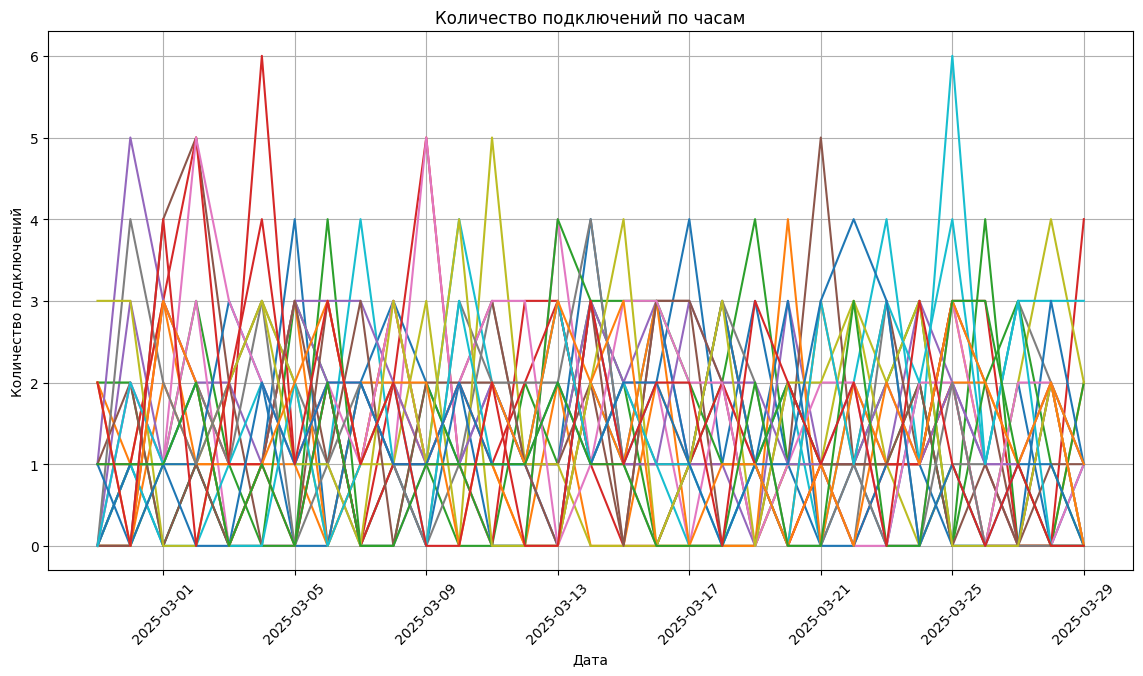

Аномальные подключения:
                             WAN IP         Proxy IP  Internal IP  \
Timestamp                                                           
2025-03-13 07:44:23   207.127.11.79   241.183.58.174  192.168.0.1   
2025-03-21 16:33:23    96.27.247.32  132.196.251.159     10.1.1.1   
2025-03-11 08:07:42   77.200.180.21   42.140.232.199  192.168.1.1   
2025-03-27 21:13:02  105.130.167.82  221.130.211.133   172.16.0.1   
2025-03-24 15:15:45   224.102.89.96    45.94.101.114     10.0.0.1   

                           MAC Address    Service  Time Spent (s)  \
Timestamp                                                           
2025-03-13 07:44:23  75:51:67:6e:10:19  Instagram          165.57   
2025-03-21 16:33:23  04:4d:21:b3:04:60   WhatsApp         5996.46   
2025-03-11 08:07:42  a0:7b:db:d8:74:05      hh.ru          277.17   
2025-03-27 21:13:02  7a:54:f5:dd:0e:2a   Facebook           10.12   
2025-03-24 15:15:45  f5:d7:49:89:3e:60   Telegram         7160.95   

        

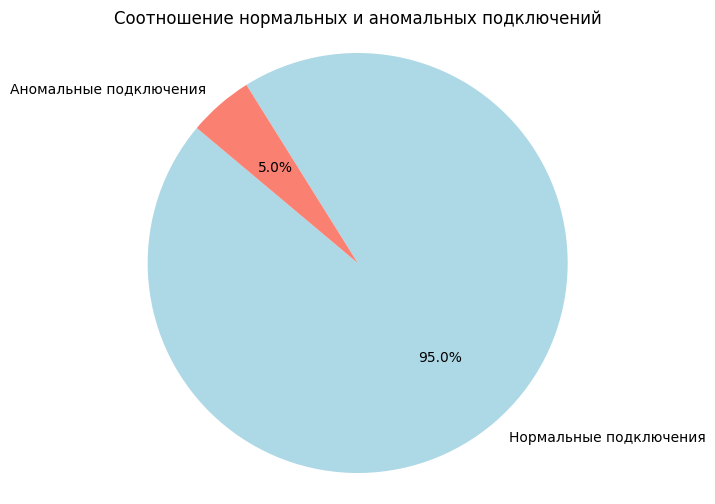

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Загрузка датасета
data = pd.read_csv('network_data.csv')

# Преобразуем временные метки в datetime формат
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data.set_index('Timestamp', inplace=True)

# Создание признаков на основе временных меток
data['hour'] = data.index.hour
data['day'] = data.index.date

# Подсчет количества подключений по времени
connections_per_hour = data.groupby(['day', 'hour']).size().unstack(fill_value=0)

# Визуализация количества подключений по времени
plt.figure(figsize=(14, 7))
plt.title('Количество подключений по часам')
plt.xlabel('Дата')
plt.ylabel('Количество подключений')
plt.plot(connections_per_hour.index, connections_per_hour.values)
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Подготовка данных для модели аномалий
# Используем 'Time Spent (s)' и 'Traffic Volume (MB)' для выявления аномалий
features = data[['Time Spent (s)', 'Traffic Volume (MB)']]

# Обучение модели для обнаружения аномалий
model = IsolationForest(contamination=0.05)  # Установите уровень загрязнения
data['anomaly'] = model.fit_predict(features)

# Выделяем аномальные подключения
anomalies = data[data['anomaly'] == -1]

# Выводим пару аномальных подключений
print("Аномальные подключения:")
print(anomalies[['WAN IP', 'Proxy IP', 'Internal IP', 'MAC Address', 'Service', 'Time Spent (s)', 'Traffic Volume (MB)']].head(5))

# Визуализация соотношения нормальных и аномальных подключений
normal_count = len(data[data['anomaly'] == 1])
anomalous_count = len(anomalies)

labels = ['Нормальные подключения', 'Аномальные подключения']
sizes = [normal_count, anomalous_count]
colors = ['lightblue', 'salmon']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Равные оси для круга
plt.title('Соотношение нормальных и аномальных подключений')
plt.show()


In [ ]:
import pandas as pd
import random

x = random.randint(0, 7200)
# Пример данных
data = {
    'ip': ['192.168.1.1', '192.168.1.2', '192.168.1.3', '192.168.1.4'],
    'mac': ['00:14:22:01:23:45', '00:14:22:01:23:46', '00:14:22:01:23:47', '00:14:22:01:23:48'],
    'network': ['Telegram', 'Google', 'Yandex', 'Instagram'],
    'time_spent': [120, 150, 90, 200],
    'timestamp': ['2025-03-22 10:00:00', '2025-03-22 11:30:00', '2025-03-22 14:45:00', '2025-03-22 16:00:00']
}

# Преобразуем данные в DataFrame
df = pd.DataFrame(data)

# Сохраняем DataFrame в CSV файл
df.to_csv('network_data.csv', index=False)

print("CSV файл был успешно создан!")


CSV файл был успешно создан!


In [ ]:
pip install pandas scikit-learn matplotlib seaborn

Общее количество подключений: 1000
Количество аномальных подключений: 50
Аномальные подключения:
              WAN IP         Proxy IP    Internal IP        MAC Address  \
5      226.43.115.67    122.99.69.200       10.1.1.1  ac:3a:da:97:b7:42   
7     116.230.55.136      173.68.8.84     172.20.0.1  ba:67:6b:f5:ee:4b   
17    183.252.247.26    13.242.31.116    192.168.1.1  82:e7:1d:b5:45:f6   
35        64.26.59.8   220.139.78.165   192.168.10.1  47:03:95:5f:8e:8d   
52    37.192.149.248   172.24.248.136     172.16.0.1  61:ce:43:e0:47:dc   
68    255.233.40.104    180.87.18.186  192.168.100.1  1d:a8:d5:9b:89:48   
70     24.252.77.237    211.252.9.137   192.168.10.1  6c:38:50:4d:17:f6   
81    197.107.78.163    32.157.65.212   192.168.50.1  79:0e:e8:ec:ec:43   
97     202.57.202.37   74.116.117.138    192.168.0.1  98:46:23:84:24:dc   
108     178.40.30.28     33.48.154.74    192.168.0.1  7d:3a:66:df:91:37   
128   106.49.252.143    181.31.77.165   192.168.10.1  46:b0:68:8b:b2:e3   
130

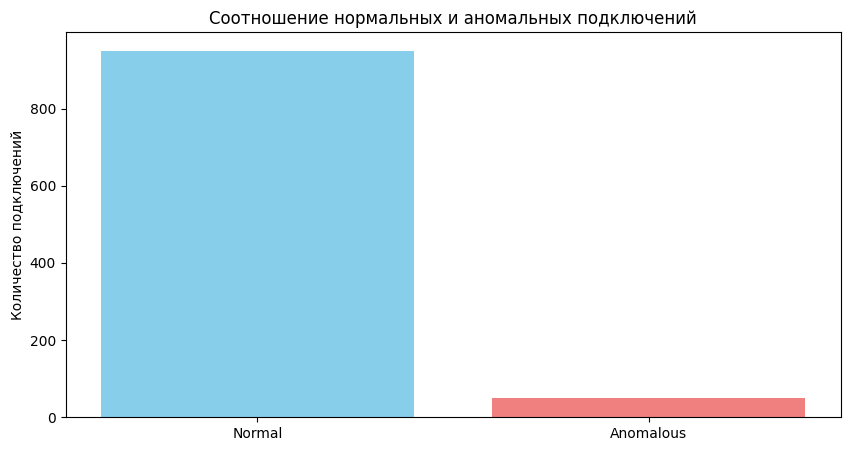

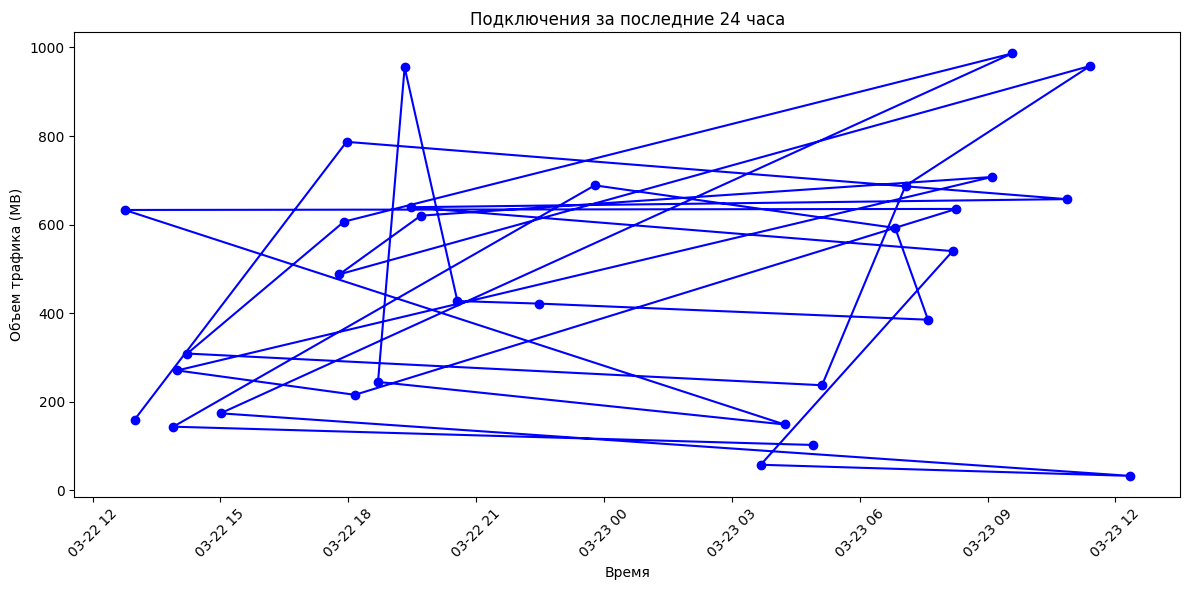

<ipython-input-19-b9d014412245>:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=network_counts.index, y=network_counts.values, palette='viridis')


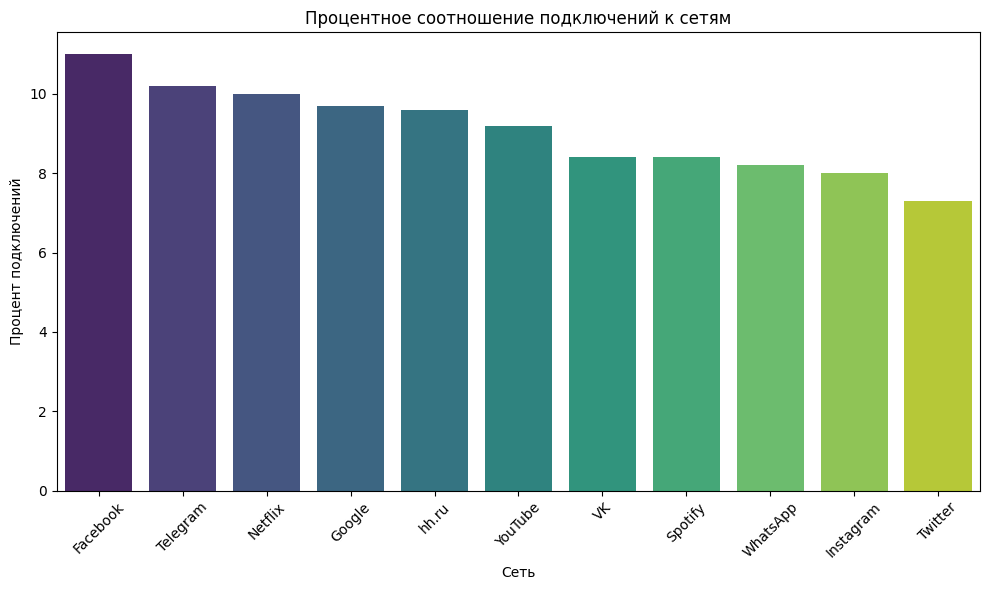

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# Шаг 1: Загрузка данных из CSV файла
def load_data(filename):
    return pd.read_csv(filename)

# Шаг 2: Обнаружение аномалий
def detect_anomalies(data):
    # Преобразуем время в datetime
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])

    # Извлекаем признаки для обучения (время в секундах и объем трафика)
    features = data[['Time Spent (s)', 'Traffic Volume (MB)']].values

    # Обучаем модель Isolation Forest
    model = IsolationForest(contamination=0.05)  # 5% данных считаем аномальными
    data['Anomaly'] = model.fit_predict(features)

    return data

# Шаг 3: Выбор аномальных подключений и вывод статистики
def select_anomalous_connections(data):
    total_connections = len(data)  # Общее количество подключений
    anomalous_connections = data[data['Anomaly'] == -1]  # Аномальные подключения
    total_anomalous = len(anomalous_connections)  # Количество аномальных подключений

    # Вывод информации
    print(f"Общее количество подключений: {total_connections}")
    print(f"Количество аномальных подключений: {total_anomalous}")

    if not anomalous_connections.empty:
        print("Аномальные подключения:")
        print(anomalous_connections)
    else:
        print("Аномальных подключений не найдено.")

    return anomalous_connections  # Возвращаем аномальные подключения, если нужно

# Шаг 4: Визуализация подключений по времени и распределение сервисов
def visualize_connections(data):
    # Создаем столбец с часами из временной метки
    data['Hour'] = data['Timestamp'].dt.hour

    # Подсчитываем количество нормальных и аномальных подключений
    normal_count = (data['Anomaly'] == 1).sum()
    anomaly_count = (data['Anomaly'] == -1).sum()

    # Визуализируем соотношение нормальных и аномальных подключений
    plt.figure(figsize=(10, 5))
    plt.bar(['Normal', 'Anomalous'], [normal_count, anomaly_count], color=['skyblue', 'lightcoral'])
    plt.title('Соотношение нормальных и аномальных подключений')
    plt.ylabel('Количество подключений')
    plt.show()

    # График подключений за последнее время (например, за последние 24 часа)
    recent_data = data[data['Timestamp'] >= (data['Timestamp'].max() - pd.Timedelta(days=1))]

    plt.figure(figsize=(12, 6))
    plt.plot(recent_data['Timestamp'], recent_data['Traffic Volume (MB)'], marker='o', linestyle='-', color='blue')
    plt.title('Подключения за последние 24 часа')
    plt.xlabel('Время')
    plt.ylabel('Объем трафика (MB)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Диаграмма процентного соотношения подключений к различным сетям
    network_counts = data['Service'].value_counts(normalize=True) * 100  # Процентное соотношение
    plt.figure(figsize=(10, 6))
    sns.barplot(x=network_counts.index, y=network_counts.values, palette='viridis')
    plt.title('Процентное соотношение подключений к сетям')
    plt.xlabel('Сеть')
    plt.ylabel('Процент подключений')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Пример использования
filename = 'network_data.csv'  # Укажите имя вашего CSV файла
data = load_data(filename)
data_with_anomalies = detect_anomalies(data)

# Выбор аномальных подключений
selected_anomalies = select_anomalous_connections(data_with_anomalies)
print("Выбранные аномальные подключения:")
print(selected_anomalies)

# Визуализация
visualize_connections(data_with_anomalies)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# Чтение данных
data = pd.read_csv('network_data.csv')  # Замените на путь к вашему датасету

# Предположим, что в вашем датасете есть такие колонки: 'ip', 'mac', 'network', 'time_spent'
# Обработка данных
data['timestamp'] = pd.to_datetime(data['timestamp'])  # Преобразуем метку времени в datetime, если нужно
data['hour'] = data['timestamp'].dt.hour  # Извлекаем час из метки времени

# Кодируем категориальные переменные
le_network = LabelEncoder()
data['network_encoded'] = le_network.fit_transform(data['network'])

# Применяем машинное обучение для поиска аномалий с помощью Isolation Forest
features = ['hour', 'network_encoded', 'time_spent']
X = data[features]

# Создаем модель для обнаружения аномалий
model = IsolationForest(contamination=0.05)  # Устанавливаем степень загрязнения (примерно 5% аномальных данных)
data['anomaly'] = model.fit_predict(X)

# Отображение аномальных и нормальных данных
sns.scatterplot(data=data, x='hour', y='time_spent', hue='anomaly', palette='coolwarm', style='anomaly')
plt.title('Аномалии в данных о подключении')
plt.xlabel('Час суток')
plt.ylabel('Время пребывания в сети (минуты)')
plt.show()

# Построение графика подключения людей по времени (24 часа)
network_visits = data.groupby(['hour', 'network'])['ip'].count().reset_index()
network_visits = network_visits.rename(columns={'ip': 'connections'})

# График подключения по времени и сети
plt.figure(figsize=(12, 6))
sns.lineplot(data=network_visits, x='hour', y='connections', hue='network', marker='o')
plt.title('Подключения людей по времени (24 часа)')
plt.xlabel('Час суток')
plt.ylabel('Количество подключений')
plt.xticks(range(24))  # Отображаем все 24 часа
plt.legend(title='Сеть')
plt.show()

# Выводим аномальные записи
anomalies = data[data['anomaly'] == -1]
print("Аномальные записи:")
print(anomalies[['ip', 'mac', 'network', 'hour', 'time_spent']])


KeyError: 'timestamp'